# Publication-Quality Plots

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


## ALL FEATURES (CLASSIFICATION)

In [2]:

# LMS
lms_imp = pd.read_csv("lms_xg_quenching.csv")
lms_metrics = pd.read_csv("lms_xg_quenching_auc.csv")

# # HMS
hms_imp = pd.read_csv("hms_xg_quenching.csv")
hms_metrics = pd.read_csv("hms_xg_quenching_auc.csv")

# # LMC
lmc_imp = pd.read_csv("lmc_xg_quenching.csv")
lmc_metrics = pd.read_csv("lmc_xg_quenching_auc.csv")

# # HMC
hmc_imp = pd.read_csv("hmc_xg_quenching.csv")
hmc_metrics = pd.read_csv("hmc_xg_quenching_auc.csv")

# ALL SATELLITES
all_satellites_imp = pd.read_csv("all_satellites_xg_quenching.csv")
all_satellites_metrics = pd.read_csv("all_satellites_xg_quenching_auc.csv")

# ALL CENTRALS
all_centrals_imp = pd.read_csv("all_centrals_xg_quenching.csv")
all_centrals_metrics = pd.read_csv("all_centrals_xg_quenching_auc.csv")

In [3]:
def four_plot(imps, metrics=None, save_path="xg_quenching_four_plot.pdf", pie_xy=(0.50, 0.20)):
    """
    4-panel (2×2) publication-quality plot of feature importances,
    vertical bars with black outlines, LaTeX feature names, y-axis on every panel,
    color-coded local vs. global parameters, inset pie charts,
    a publication-style legend in Times New Roman, and black subplot borders.

    Parameters
    ----------
    imps : list of pd.DataFrame
        4 DataFrames (LMS, HMS, LMC, HMC) with
        'imp_feature', 'imp_importance', 'imp_std'.
    metrics : list of pd.DataFrame, optional
        (unused here; reserved for future extensions)
    save_path : str, optional
        Path to save figure (PDF/SVG).
    pie_xy : tuple of floats
        (x, y) position within each axes (in axes fraction) to place
        the inset pie chart.
    """
    # LaTeX + Times New Roman via newtx
    plt.rcParams.update({
        "text.usetex": False,
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
    })
    import seaborn as sns
    sns.set_style("whitegrid")
    sns.set_context("paper", font_scale=1.4)

    local_features = {'bin_radii', 'avg_s_mass'}
    intrinsic_global_features = {'s_mass', 'BHMass', 'bulge', 'BH_AGN'}
    environmental_global_features = {'Mhalo', 'overdens'}
    local_color = '#EEDD88'
    intrinsic_global_color = '#FFAABB'
    environmental_global_color = '#99DDFF'

    latex_labels = {
        'bin_radii':     r'$r/R_e$',
        'avg_s_mass':   r'$\Sigma_{{*}}$',
        's_mass':        r'$M_{{*}}$',
        'BHMass':       r'$M_{{BH}}$',
        'Mhalo':        r'$M_{{h}}$',
        'bulge':        r'$F(G, M_{{20}})$',
        'overdens':     r'$\delta_{{5}}$',
        'BH_AGN':       r'$\Sigma E_{{AGN}}$',

    }
    # Order: [LMC, LMS, HMC, HMS] for correct subplot placement
    names = [ 'All Centrals', 'All Satellites', 'Low Mass Satellites', 'High Mass Satellites']
    # Rearranged imps for subplot order: [LMC, LMS, HMC, HMS]
    # imps = [imps[0], imps[1], imps[2], imps[3]]

    max_imp = max((df['Mean Importance'] + df['Std Dev']).max() for df in imps) * 1.1

    fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharey=False)
    axes = axes.flatten()

    for i, (df, ax, label) in enumerate(zip(imps, axes, names)):
        df = df.sort_values('Mean Importance', ascending=False).copy()
        df['orig_feature'] = df['Feature']
        df['Feature'] = df['Feature'].map(lambda x: latex_labels.get(x, x))

        colors = [local_color if feat in local_features else intrinsic_global_color if feat in intrinsic_global_features else environmental_global_color for feat in df['orig_feature']]
        ax.bar(
            df['Feature'], df['Mean Importance'], yerr=df['Std Dev'],
            capsize=4, color=colors, edgecolor='black', linewidth=0.8, alpha=0.9
        )

        # Black border around subplot
        for spine in ax.spines.values():
            spine.set_edgecolor('black')
            spine.set_linewidth(0.8)

        ax.set_title(label, fontsize=20)
        ax.set_ylim(0, max_imp)
        ax.grid(axis='y', linestyle='--', alpha=0.5)
        ax.grid(False, axis='x')
        ax.tick_params(axis='x', labelrotation=45, labelsize=17)
        ax.tick_params(axis='y', labelsize=17)
        ax.set_ylabel(r'Relative Importance', fontsize=20)
    
        
        # Inset pie chart (percentages inside the pie)
        x0, y0 = pie_xy
        # Increase the width and height from 0.45 to a larger value, e.g., 0.6
        axins = ax.inset_axes([x0, y0, 0.6, 0.6], transform=ax.transAxes)
        local_sum = df.loc[df['orig_feature'].isin(local_features), 'Mean Importance'].sum()
        intrinsic_global_sum = df.loc[df['orig_feature'].isin(intrinsic_global_features), 'Mean Importance'].sum()
        environmental_global_sum = df.loc[df['orig_feature'].isin(environmental_global_features), 'Mean Importance'].sum()
        values = [local_sum, intrinsic_global_sum, environmental_global_sum]
        labels = ['Local', 'Intr.', 'Env.']
        wedges, texts, autotexts = axins.pie(
            values,
            colors=[local_color, intrinsic_global_color, environmental_global_color],
            startangle=90,
            wedgeprops={'alpha': 0.7, 'linewidth': 0.5, 'edgecolor': 'black'},
            labels=labels,
            autopct=lambda pct: f"{pct:.0f}%",
            textprops={'fontsize': 15}
        )


        # Sum for percentage calculation
        total = sum(values)

        # Collect labels for under-pie display
        small_labels = []

        for text, autotext, value in zip(texts, autotexts, values):
            # Calculate percentage
            pct = value / total * 100 if total > 0 else 0
            text.set_fontsize(15)
            autotext.set_fontsize(15)

            # If percentage < 0.5%, put under the pie chart
            if pct < 0.5:
                # Completely invisible on pie
                text.set_visible(False)
                autotext.set_visible(False)
                small_labels.append(f"{text.get_text()} (0%)")

            # If percentage < 5%, move percentage label outside pie chart
            elif pct < 5:
                # Hide the percentage inside the pie
                autotext.set_visible(False)

                # Move label outward
                x, y = text.get_position()
                text.set_position((1.2 * x, 1.2 * y))
                # Add percentage manually next to label
                text.set_text(f"{text.get_text()} ({pct:.0f}%)")

                # Leader line from wedge to label
                axins.plot([0.9 * x, 1.1 * x], [0.9 * y, 1.1 * y], color='black', lw=0.7, zorder=0)

            else:
                # Standard case: label outside, percentage inside
                x, y = text.get_position()
                text.set_position((1.2 * x, 1.25 * y))
                # Leader line
                axins.plot([0.9 * x, 1.1 * x], [0.9 * y, 1.1 * y], color='black', lw=0.7, zorder=0)

        # Display small 0% labels underneath the pie chart
        if small_labels:
            label_str = "\n".join(small_labels)
            axins.text(0, -1.45, label_str, ha='center', va='top', fontsize=15, transform=axins.transData)

        # Keep pie chart circular
        axins.set_aspect('equal')


        for i, (df, ax) in enumerate(zip(metrics, axes)):
            # Strip whitespace from column names
            df.columns = df.columns.str.strip()

            # Extract AUC values from the 1-row DataFrame
            train_auc = df['Train AUC'].iloc[0]
            test_auc = df['Test AUC'].iloc[0]

            # Annotate the specific subplot (ax)
            textstr = f"Train AUC = {train_auc:.2f}\nTest AUC = {test_auc:.2f}"
            ax.text(0.72, 0.95, textstr, transform=ax.transAxes,
                    fontsize=15, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

    
    # Legend
    handles = [
        plt.Line2D([0], [0], marker='s', color=local_color, lw=0, markersize=10, label='Local'),
        plt.Line2D([0], [0], marker='s', color=intrinsic_global_color, lw=0, markersize=10, label='Intrinsic Global'),
        plt.Line2D([0], [0], marker='s', color=environmental_global_color, lw=0, markersize=10, label='Environmental Global')
    ]
    legend = fig.legend(handles=handles, loc='center', bbox_to_anchor=(0.02, 0.98),
                        frameon=True, edgecolor='black', fontsize=16)
    legend.get_frame().set_linewidth(0.8)

    # Remove the overall title
    plt.tight_layout(rect=[0, 0.02, 1, 0.98])
    # fig.suptitle("XGBoost Quenching Classification", fontsize=24, fontweight='bold', y=1.02)


    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()

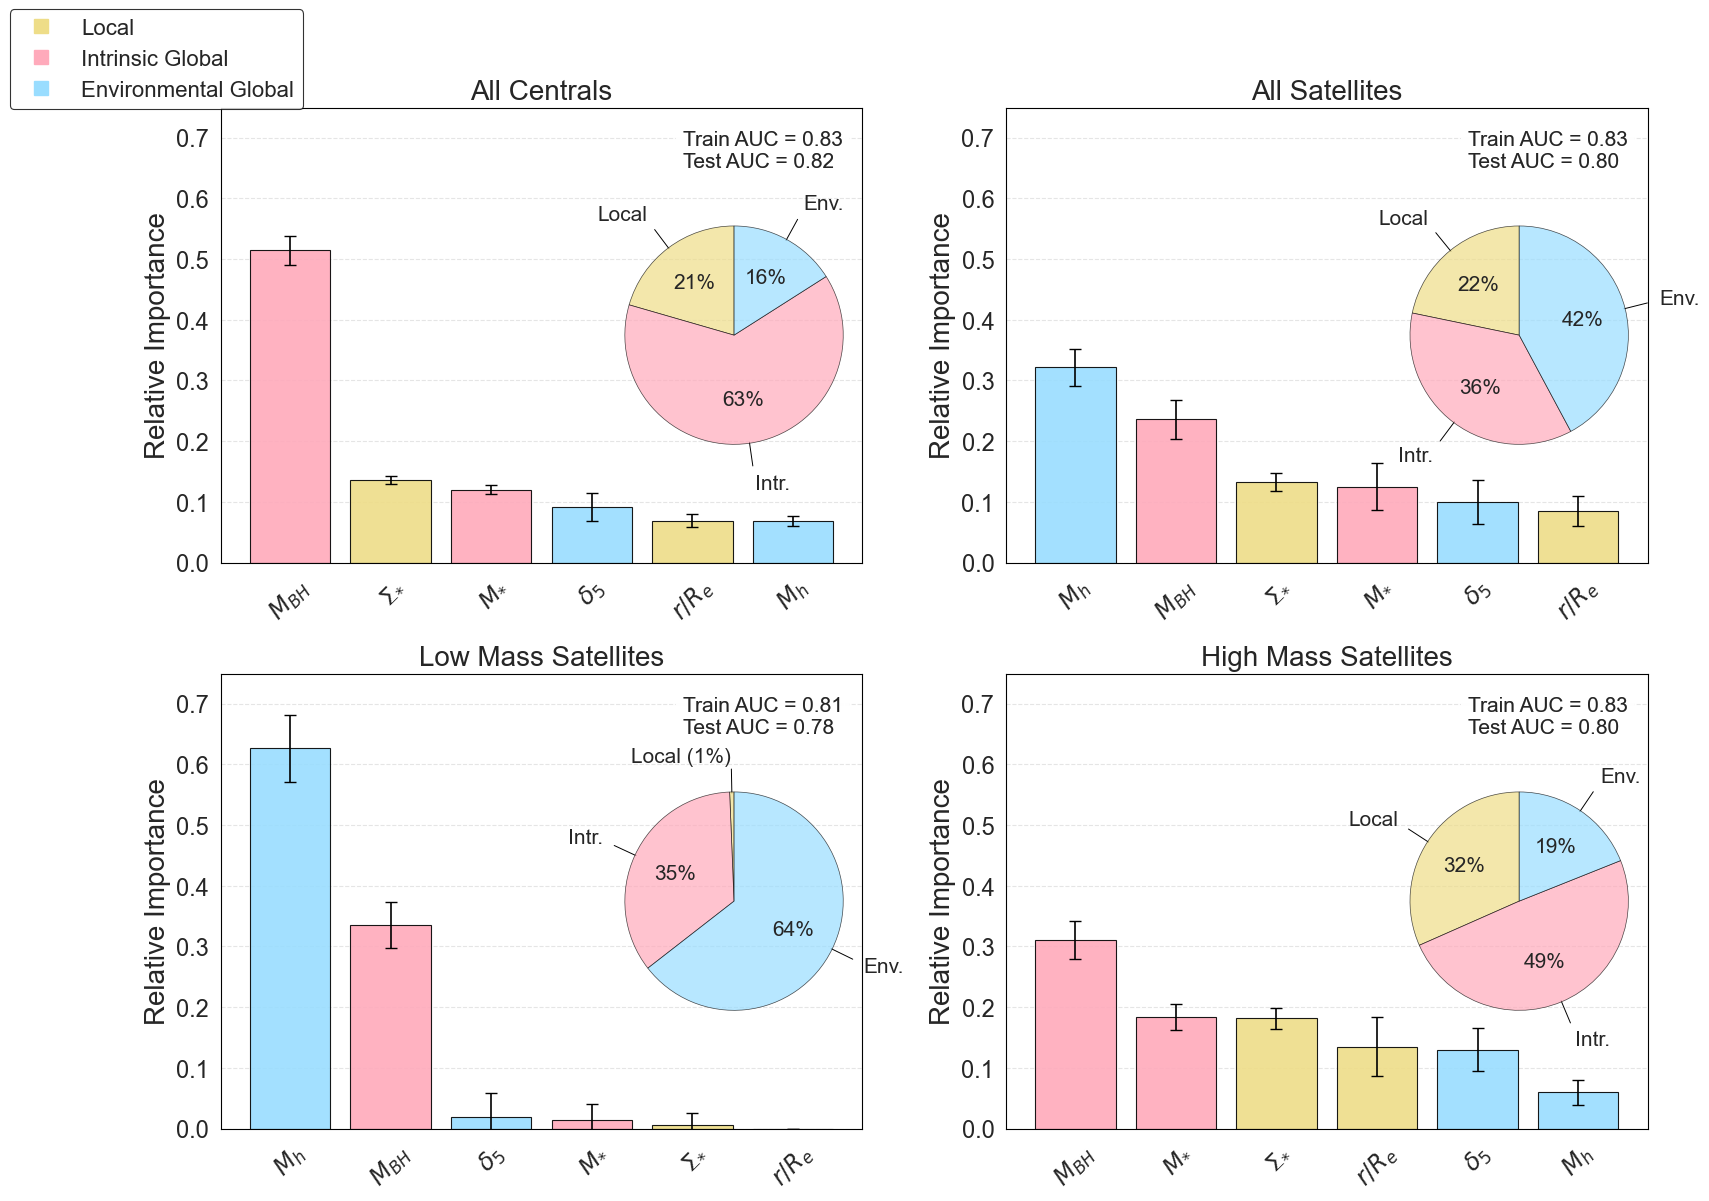

In [4]:
four_imps = [all_centrals_imp, all_satellites_imp, lms_imp, hms_imp]
four_metrics = [all_centrals_metrics,all_satellites_metrics,lms_metrics,hms_metrics]
four_plot(four_imps, four_metrics)